# Noise covariances and the Gaussian likelihood

A Gaussian likelihood needs one input beyond the forward model: the noise covariance $C$. For data
$d$ and a source $m$,

$$\log L(m) = -\tfrac12\,(d - G^\mathsf{T} m)^\mathsf{T} C^{-1} (d - G^\mathsf{T} m).$$

This notebook shows how the choice of $C$ changes the posterior. It generates coloured synthetic noise and
estimates its covariance from noise windows, as a real study estimates it from recorded noise. It
then builds every covariance model the library ships: white noise, per-station white noise, three
stationary block models, and data noise plus theory error from an ensemble of Earth models. Theory
error is the part of the misfit that comes from the Earth model rather than from the noise. Each
covariance gives a posterior by score compression, and the posteriors are tested on data from the
reference Earth and from an Earth 1.5 % faster.

Requirements: `INSTASEIS_DB` pointing at a local Instaseis database. Nothing is downloaded. The
notebook runs in under a minute. The first cell fixes the constants: a
200 s window at 1 Hz, a 0.02-0.08 Hz band pass, the source position and the true moment tensor.

In [1]:
import os
import tempfile
from pathlib import Path

import numpy as np

INSTASEIS_DB = os.environ["INSTASEIS_DB"]
SAMPLING_RATE_HZ = 1.0
DURATION_S = 200
FILTER_BAND = {"type": "bandpass", "freqmin": 0.02, "freqmax": 0.08, "corners": 4, "zerophase": False}
PROCESSING = {"filter": FILTER_BAND, "sampling_rate": SAMPLING_RATE_HZ, "filter_sampling_rate": 5.0}
SOURCE_LOCATION = [37.636, -118.936, 10.0, 0.0]  # latitude, longitude, depth_km, time shift s
TRUE_MOMENT_TENSOR = np.array([1.0e17, -0.6e17, -0.4e17, 0.3e17, -0.5e17, 0.2e17])  # N m
PARAMETER_NAMES = ["m_rr", "m_tt", "m_pp", "m_rt", "m_rp", "m_tp"]
scratch = Path(tempfile.mkdtemp())

## A linear forward model

Five stations record the vertical component. At a fixed source position the data are linear in the
moment tensor, $d = G^\mathsf{T} m$. The sensitivity kernels $G$, shape `(6, n_data)`, are the
synthetics of the six unit moment tensors, one Instaseis run each. The next cell builds the
receivers and the simulator, computes the kernels and the noise-free data of the true tensor, and
prints their size.

In [2]:
from seismo_sbi.simulators.simulation_io import SYNTHETICS_PRE_EVENT_PAD_S
from seismo_sbi.simulators.instaseis.simulator import InstaseisSourceSimulator
from seismo_sbi.simulators.receivers import Receivers
from seismo_sbi.simulators.simulation_io import SimulationDataLoader, seismogram_map_to_array

receivers = Receivers(receivers=[receiver._replace(components=["Z"]) for receiver in
                                  Receivers.from_station_file("configs/stations.txt").iterate()])
instaseis_simulator = InstaseisSourceSimulator(
    INSTASEIS_DB, components="Z", receivers=receivers,
    seismogram_duration_in_s=DURATION_S, synthetics_processing=PROCESSING)
data_loader = SimulationDataLoader("Z", receivers)




kernels = np.array([seismogram_map_to_array(instaseis_simulator.run_simulation(
    {"source_location": SOURCE_LOCATION, "moment_tensor": list(unit)})[1], receivers)
    for unit in np.eye(6) * 1e17]) / 1e17
n_traces = len(receivers)
trace_length = kernels.shape[1] // n_traces
clean_data = kernels.T @ TRUE_MOMENT_TENSOR
time_after_origin_s = np.arange(trace_length) / SAMPLING_RATE_HZ - SYNTHETICS_PRE_EVENT_PAD_S
print(f"{n_traces} traces of {trace_length} samples; peak signal {np.abs(clean_data).max():.2e} m")

5 traces of 201 samples; peak signal 1.02e-04 m


The five stations (triangles) and the source (star). The stations lie 60 to 300 km from the source, all to its west, so the azimuthal coverage is one-sided.

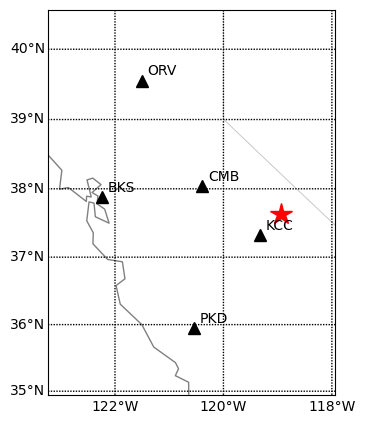

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

latitudes = [receiver.latitude for receiver in receivers.iterate()] + [SOURCE_LOCATION[0]]
longitudes = [receiver.longitude for receiver in receivers.iterate()] + [SOURCE_LOCATION[1]]
fig, ax = plt.subplots(figsize=(6, 5))
region = Basemap(projection="merc", llcrnrlat=min(latitudes) - 1, urcrnrlat=max(latitudes) + 1,
                 llcrnrlon=min(longitudes) - 1, urcrnrlon=max(longitudes) + 1, resolution="l", ax=ax)
region.drawcoastlines(color="0.5")
region.drawstates(color="0.8")
region.drawparallels(range(30, 45), labels=[1, 0, 0, 0]), region.drawmeridians(range(-126, -110, 2), labels=[0, 0, 0, 1])
for receiver in receivers.iterate():
    x, y = region(receiver.longitude, receiver.latitude)
    ax.plot(x, y, "k^", ms=8), ax.annotate(receiver.station_name, (x, y), xytext=(4, 4), textcoords="offset points")
ax.plot(*region(SOURCE_LOCATION[1], SOURCE_LOCATION[0]), "r*", ms=16)
plt.show()

## Coloured noise and the empirical estimate of its covariance

The "true" noise is stationary, with the damped-cosine autocovariance of Kolb et al.,

$$c(\tau) = \sigma^2 e^{-\lambda|\tau|}\cos(\lambda\omega_0\tau),$$

and a different $\sigma$ at each station. `BlockDiagonalKolbCovariance` holds it as one Toeplitz
block per trace (a covariance that depends on the lag $\tau$ only), and its sampler draws from it.
The next cell writes 300 noise windows to disk in the layout of a noise archive, and
`EmpiricalCovarianceEstimator` measures every trace's autocovariance from them. The figure compares
the true and the estimated autocovariance at three stations.

Computing empirical covariance matrix... Done. 

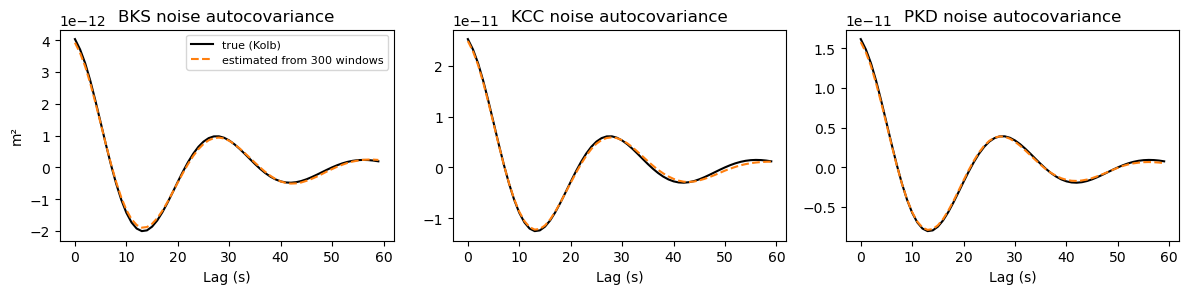

In [4]:
import h5py

from seismo_sbi.sbi.noises.covariance_estimator import EmpiricalCovarianceEstimator
from seismo_sbi.sbi.noises.toeplitz_covariances import BlockDiagonalKolbCovariance

noise_sigma_m = dict(zip([r.station_name for r in receivers.iterate()], [2e-6, 3e-6, 5e-6, 2.5e-6, 4e-6]))
noise_variances = {station: {"Z": sigma ** 2} for station, sigma in noise_sigma_m.items()}
true_covariance = BlockDiagonalKolbCovariance(noise_variances, receivers=receivers,
                                              data_vector_length=trace_length, num_jobs=1)
true_noise_sampler = true_covariance.create_sampler()

np.random.seed(0)
noise_directory = scratch / "noise"
noise_directory.mkdir()
for window in range(300):
    noise = true_noise_sampler.draw().noise.reshape(n_traces, trace_length)
    with h5py.File(noise_directory / f"noise_{window:03d}.h5", "w") as noise_file:
        for receiver, trace in zip(receivers.iterate(), noise):
            noise_file.create_dataset(f"outputs/{receiver.station_name}/Z", data=trace)

estimated_autocovariances = EmpiricalCovarianceEstimator(
    noise_directory, receivers, "Z", covariance_exp_tapering=False).compute_stationwise_covariances()

lags_s = np.arange(60) / SAMPLING_RATE_HZ
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, (index, station) in zip(axes, [(0, "BKS"), (2, "KCC"), (4, "PKD")]):
    ax.plot(lags_s, true_covariance.toeplitz_cols_list[index][:60], "k", label="true (Kolb)")
    ax.plot(lags_s, estimated_autocovariances[station]["Z"][:60], "C1--", label="estimated from 300 windows")
    ax.set_title(f"{station} noise autocovariance")
    ax.set_xlabel("Lag (s)")
axes[0].set_ylabel("m²")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## A theory-error covariance from an ensemble of Earth models

Theory error is the spread of the synthetics over plausible Earth models.
`EnsembleTheoryCovarianceEstimationSimulator` runs any ensemble simulator (a
`GFEnsembleSimulator`) once per member and returns each trace's covariance about the reference
member. Real ensembles are Instaseis or CPS databases built on perturbed 1-D models. Here a toy
ensemble stands in for them: each of its 30 members stretches the time axis of the reference
seismograms, which is the effect of an Earth uniformly faster or slower by about 1 %. The next cell
defines that ensemble and estimates the theory covariance from it.

In [5]:
from seismo_sbi.simulators.gf_ensemble import GFEnsembleSimulator
from seismo_sbi.simulators.theory_covariance import EnsembleTheoryCovarianceEstimationSimulator


def stretch_time_axis(data, velocity_factor):
    """Flat data vector as recorded in an Earth ``velocity_factor`` times faster."""
    return np.concatenate([np.interp(time_after_origin_s * velocity_factor, time_after_origin_s, trace)
                           for trace in data.reshape(n_traces, trace_length)])


class StretchedKernelEnsemble(GFEnsembleSimulator):
    """Kernel seismograms with the time axis stretched by one member's velocity factor."""

    def __init__(self, kernels, velocity_factors, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.kernels = kernels
        self.velocity_factors = list(velocity_factors)

    @property
    def members(self):
        return self.velocity_factors

    @property
    def fiducial_member(self):
        return 1.0

    def generic_point_source_simulation(self, source, use_fiducial=None, **kwargs):
        velocity_factor = self.select_member(use_fiducial=bool(use_fiducial))
        data = stretch_time_axis(self.kernels.T @ source.moment_tensor.components, velocity_factor)
        return {receiver.station_name: {"Z": trace} for receiver, trace
                in zip(self.receivers.iterate(), data.reshape(n_traces, trace_length))}


np.random.seed(1)
ensemble = StretchedKernelEnsemble(kernels, np.random.normal(1.0, 0.01, 30), components="Z",
                                   receivers=receivers, seismogram_duration_in_s=DURATION_S,
                                   synthetics_processing=PROCESSING)
theory_estimator = EnsembleTheoryCovarianceEstimationSimulator(
    ensemble, data_loader.convert_sim_data_to_array, components="Z", receivers=receivers, seismogram_duration_in_s=DURATION_S,
    synthetics_processing=PROCESSING, internal_jobs=1)
theory_blocks = seismogram_map_to_array(theory_estimator.run_simulation(
    {"source_location": SOURCE_LOCATION, "moment_tensor": list(TRUE_MOMENT_TENSOR)})[1], receivers)
print("theory covariance: one", trace_length, "x", trace_length, "block per trace, total size", theory_blocks.size)

theory covariance: one 201 x 201 block per trace, total size 202005


The vertical trace at the first station in the reference Earth (black) and in five members of the ensemble
(colours). A one per cent change in velocity moves the arrival at 100 s by about one second. The members differ most where the waveform is steepest, and the theory covariance is largest there.

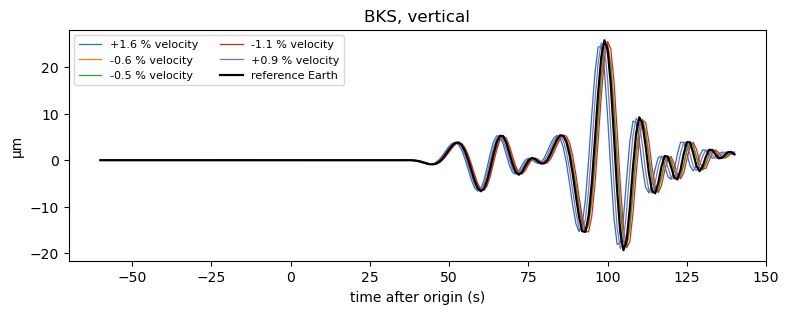

In [6]:
station = receivers.receivers[0].station_name
fig, ax = plt.subplots(figsize=(9, 3))
for velocity_factor in ensemble.velocity_factors[:5]:
    ax.plot(time_after_origin_s, stretch_time_axis(clean_data, velocity_factor)[:trace_length] * 1e6, lw=0.9,
            label=f"{100 * (velocity_factor - 1):+.1f} % velocity")
ax.plot(time_after_origin_s, clean_data[:trace_length] * 1e6, "k", lw=1.6, label="reference Earth")
ax.set(xlabel="time after origin (s)", ylabel="µm", title=f"{station}, vertical")
ax.legend(fontsize=8, ncol=2)
plt.show()

## Every covariance model

The next cell builds one instance of each covariance class from the estimates above. The table says
what each class assumes and what it is built from.

| class | noise model | built from |
|---|---|---|
| `ScalarEmpiricalCovariance` | white, one $\sigma$ for all samples | a noise level |
| `DiagonalEmpiricalCovariance` | white, one variance per trace | the estimated lag-0 variances |
| `BlockDiagonalEmpiricalCovariance` | stationary, one Toeplitz block per trace | the estimated autocovariances, tapered by $e^{-\tau/20}$ |
| `BlockDiagonalFilteredCovariance` | band-limited white noise per trace | variances and the filter band |
| `BlockDiagonalKolbCovariance` | damped cosine per trace | variances (the truth here) |
| `TheoryBlockDiagonalEmpiricalCovariance` | data noise plus theory error | theory blocks and a data covariance |

In [7]:
from copy import deepcopy

from seismo_sbi.sbi.compression.gaussian import ScoreCompressionData
from seismo_sbi.sbi.noises.covariance_estimator import build_cov_sigma2_dict
from seismo_sbi.sbi.noises.diagonal_covariances import DiagonalEmpiricalCovariance, ScalarEmpiricalCovariance
from seismo_sbi.sbi.noises.theory_block_covariance import TheoryBlockDiagonalEmpiricalCovariance
from seismo_sbi.sbi.noises.toeplitz_covariances import (BlockDiagonalEmpiricalCovariance,
                                                        BlockDiagonalFilteredCovariance)

estimated_variances = build_cov_sigma2_dict(estimated_autocovariances)
estimated_variances_z = [variances["Z"] for variances in estimated_variances.values()]
covariances = {
    "scalar": ScalarEmpiricalCovariance(np.sqrt(np.mean(list(estimated_variances_z))),
                                        data_vector_length=n_traces * trace_length),
    "diagonal": DiagonalEmpiricalCovariance(estimated_autocovariances, receivers, trace_length),
    "empirical": BlockDiagonalEmpiricalCovariance(deepcopy(estimated_autocovariances), receivers,
                                                  trace_length, num_jobs=1),  # it tapers its input in place
    "filtered": BlockDiagonalFilteredCovariance(estimated_variances, FILTER_BAND, receivers,
                                                trace_length, num_jobs=1),
    "Kolb (truth)": true_covariance,
    "theory + Kolb": TheoryBlockDiagonalEmpiricalCovariance(
        ScoreCompressionData(None, theory_blocks, None, None), true_covariance,
        receivers, trace_length, num_jobs=1),
}
for name, covariance in covariances.items():
    print(f"{name:14s} {type(covariance).__name__}")

scalar         ScalarEmpiricalCovariance
diagonal       DiagonalEmpiricalCovariance
empirical      BlockDiagonalEmpiricalCovariance
filtered       BlockDiagonalFilteredCovariance
Kolb (truth)   BlockDiagonalKolbCovariance
theory + Kolb  TheoryBlockDiagonalEmpiricalCovariance


Samples 130-200 of the first trace's block in each covariance model, the window where the waves arrive. The five noise models share one colour scale; the theory + Kolb model, whose theory part is far larger, has its own. The scalar and diagonal models put all the noise on the diagonal. The empirical, filtered and Kolb blocks spread it along bands several samples wide, the correlation of band-passed noise, and the filtered model rings more than the truth. The theory part is ten times the noise where the waves are largest, around sample 160 (100 s after the origin).

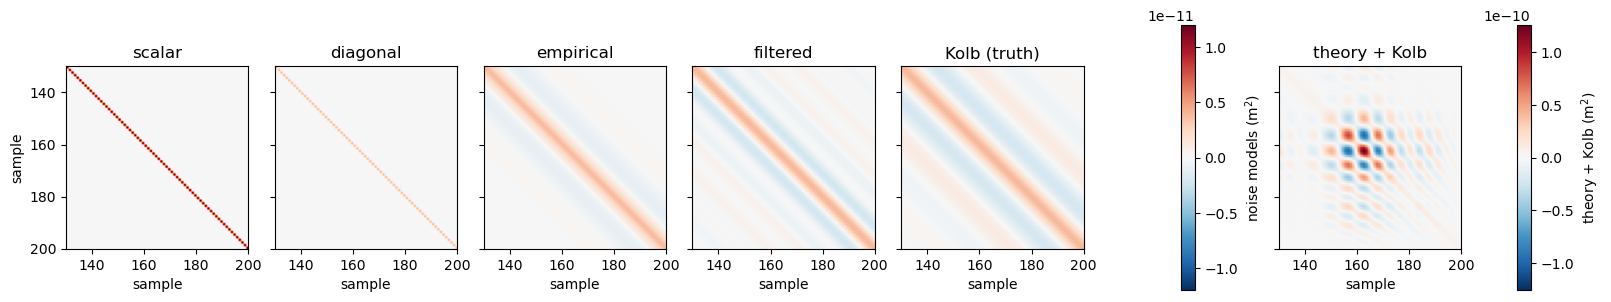

In [8]:
blocks = {name: (np.eye(trace_length) * covariance.noise_level ** 2 if name == "scalar"
                 else np.asarray(covariance.covariance_matrix_arrays[0]))
          for name, covariance in covariances.items()}
window = slice(130, 200)
noise_scale = max(np.abs(block[window, window]).max() for name, block in blocks.items() if name != "theory + Kolb")
fig, axes = plt.subplots(1, 6, figsize=(16, 3.4), sharey=True, layout="constrained")
images = {}
for ax, (name, block) in zip(axes, blocks.items()):
    scale = np.abs(block[window, window]).max() if name == "theory + Kolb" else noise_scale
    images[name] = ax.imshow(block[window, window], cmap="RdBu_r", vmin=-scale, vmax=scale,
                             extent=(window.start, window.stop, window.stop, window.start))
    ax.set(title=name, xlabel="sample")
axes[0].set_ylabel("sample")
fig.colorbar(images["Kolb (truth)"], ax=axes[:5].tolist(), shrink=0.8, label="noise models (m$^2$)")
fig.colorbar(images["theory + Kolb"], ax=axes[5], shrink=0.8, label="theory + Kolb (m$^2$)")
plt.show()

## Observed data and score compression

The observed data are the synthetics of an Earth 1.5 % faster than the reference, plus one draw of
the true noise. `GaussianCompressor` compresses a data vector to

$$\hat m = m_\mathrm{fid} + F^{-1}\nabla_m \log L, \qquad F = G C^{-1} G^\mathsf{T},$$

where $F$ is the Fisher matrix. For a linear model, $\hat m$ is exactly the maximum-likelihood
estimate and $F^{-1}$ is the posterior covariance under a flat prior: the analytical posterior.
The next cell checks the compressor against the dense matrix formula once. It then asks how far the
true source lies from each posterior's mean, as

$$\chi^2 = (m_\mathrm{true} - \hat m)^\mathsf{T} F\, (m_\mathrm{true} - \hat m),$$

with 6 degrees of freedom. A posterior that is honest about its width gives $\chi^2 < 12.6$ in 95 %
of cases. The table prints the posterior standard deviation of $m_{rr}$ and the $\chi^2$ of the
truth, on data from the reference Earth and from the faster Earth.

In [9]:
from scipy.linalg import block_diag

from seismo_sbi.sbi.compression.gaussian import GaussianCompressor

np.random.seed(3)
observed_data = stretch_time_axis(clean_data, 1.015) + true_noise_sampler.draw().noise
score_compression_data = ScoreCompressionData(
    theta_fiducial=np.zeros(6), data_fiducial=np.zeros(kernels.shape[1]),
    data_parameter_gradients=kernels, second_order_gradients=None)
compressors = {name: GaussianCompressor(score_compression_data, covariance)
               for name, covariance in covariances.items()}

dense_covariance = block_diag(*covariances["empirical"].covariance_matrix_arrays)
weighted_kernels = np.linalg.solve(dense_covariance, kernels.T)
dense_estimate = np.linalg.solve(kernels @ weighted_kernels, weighted_kernels.T @ observed_data)
compressed = compressors["empirical"].compress_data_vector(observed_data)
assert np.allclose(compressed, dense_estimate, rtol=1e-6)
print("score compression equals the dense least-squares solution: True")

analytic_posteriors = {name: (compressor.compress_data_vector(observed_data), compressor.Fisher_mat_inverse)
                       for name, compressor in compressors.items()}
reference_earth_data = clean_data + observed_data - stretch_time_axis(clean_data, 1.015)


def chi2_of_truth(compressor, data):
    offset = TRUE_MOMENT_TENSOR - compressor.compress_data_vector(data)
    return offset @ compressor.Fisher_mat @ offset


print(f"{'':14s} {'posterior std':>14s}  {'chi2 of the truth':^32s}")
print(f"{'covariance':14s} {'of m_rr (N m)':>14s}  {'reference Earth':>16s}{'faster Earth':>16s}")
for name, compressor in compressors.items():
    print(f"{name:14s} {np.sqrt(compressor.Fisher_mat_inverse[0, 0]):14.2e}  "
          f"{chi2_of_truth(compressor, reference_earth_data):16.1f}{chi2_of_truth(compressor, observed_data):16.1f}")

score compression equals the dense least-squares solution: True
                posterior std         chi2 of the truth        
covariance      of m_rr (N m)   reference Earth    faster Earth
scalar               2.67e+15               7.4           642.2
diagonal             2.36e+15               6.7           982.5
empirical            2.62e+15               1.1          1147.8
filtered             4.03e+14             179.3         58201.5
Kolb (truth)         1.96e+15               2.4          2152.5
theory + Kolb        4.93e+15               1.5             1.9


The table as a figure: the posterior standard deviation of $m_{rr}$ under each covariance, and the $\chi^2$ of
the true tensor for data from both Earths. A calibrated posterior gives a $\chi^2$ below 12.6, the 95 %
quantile for six parameters, 95 % of the time. Only the theory + Kolb covariance keeps the true tensor's $\chi^2$ below 12.6 for both Earths, with a posterior about twice as wide as the others. The filtered covariance gives the narrowest posterior and misses the truth even in the reference Earth.

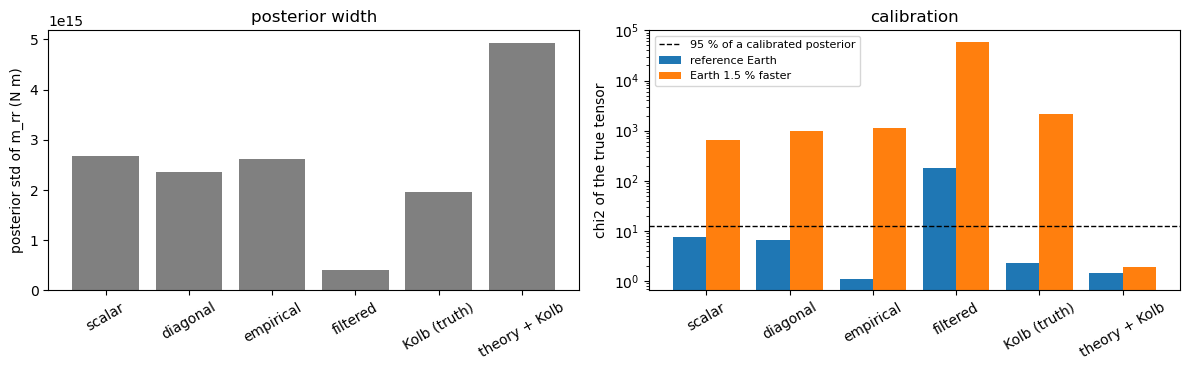

In [10]:
names = list(compressors)
chi2_values = {"reference Earth": [chi2_of_truth(compressors[name], reference_earth_data) for name in names],
               "Earth 1.5 % faster": [chi2_of_truth(compressors[name], observed_data) for name in names]}
fig, (ax_sigma, ax_chi2) = plt.subplots(1, 2, figsize=(12, 3.8))
ax_sigma.bar(names, [np.sqrt(compressors[name].Fisher_mat_inverse[0, 0]) for name in names], color="0.5")
ax_sigma.set(ylabel="posterior std of m_rr (N m)", title="posterior width")
for offset, (earth, values) in zip((-0.2, 0.2), chi2_values.items()):
    ax_chi2.bar(np.arange(len(names)) + offset, values, width=0.4, label=earth)
ax_chi2.axhline(12.6, color="k", ls="--", lw=1, label="95 % of a calibrated posterior")
ax_chi2.set(xticks=range(len(names)), xticklabels=names, yscale="log", ylabel="chi2 of the true tensor",
            title="calibration")
ax_chi2.legend(fontsize=8)
for ax in (ax_sigma, ax_chi2):
    ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

With data from the reference Earth, every posterior but the filtered one covers the truth. The
filtered model believes there is no noise outside the pass band, so it is overconfident. With data
from the faster Earth, every covariance of the data noise alone gives a posterior far too narrow for
where the truth lies. Adding the theory covariance widens the posterior enough to cover it.